In [1]:
pip install numpy pandas matplotlib scikit-learn jupyter tensorflow keras seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ──────────────────────────────────────────────────────────
# 0. IMPORTS
# ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version :", tf.__version__)
print("GPU available       :", bool(tf.config.list_physical_devices('GPU')))

TensorFlow version : 2.20.0
GPU available       : False


In [3]:
# ──────────────────────────────────────────────────────────
# 1. HYPERPARAMETERS  (change these to experiment)
# ──────────────────────────────────────────────────────────
NUM_WORDS   = 10_000   # vocabulary size (keep only top-10k words)
MAX_LEN     = 256      # truncate/pad reviews to this length
EMBED_DIM   = 64       # embedding size
HIDDEN_DIM  = 64       # neurons per hidden layer
DROPOUT     = 0.4      # dropout rate
BATCH_SIZE  = 512
EPOCHS      = 20
SEED        = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
# ──────────────────────────────────────────────────────────
# 2. LOAD & EXPLORE DATA
# ──────────────────────────────────────────────────────────
print("\n[1] Loading IMDB dataset …")
(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f"    Training samples : {len(x_train_raw):,}")
print(f"    Test samples     : {len(x_test_raw):,}")
print(f"    Unique labels    : {np.unique(y_train)}  (0=Negative, 1=Positive)")
print(f"    Class balance    : {np.mean(y_train)*100:.1f}% positive")

# Show a decoded review for intuition
word_index = imdb.get_word_index()
reverse_index = {v+3: k for k, v in word_index.items()}
reverse_index.update({0:"<PAD>", 1:"<START>", 2:"<UNK>", 3:"<UNUSED>"})

sample_review = " ".join(reverse_index.get(i, "?") for i in x_train_raw[0])
print(f"\n--- Sample review (label={'Positive' if y_train[0]==1 else 'Negative'}) ---")
print(sample_review[:300], "…\n")



[1] Loading IMDB dataset …
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 39s 2us/step
    Training samples : 25,000
    Test samples     : 25,000
    Unique labels    : [0 1]  (0=Negative, 1=Positive)
    Class balance    : 50.0% positive
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step

--- Sample review (label=Positive) ---
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the …



In [5]:
# ──────────────────────────────────────────────────────────
# 3. PRE-PROCESSING — two approaches shown
# ──────────────────────────────────────────────────────────
# Approach A: Multi-hot (bag-of-words) vectorisation  ←  simple, fast
# Approach B: Padded sequences + Embedding layer       ←  captures order

def multi_hot_encode(sequences, dimension=NUM_WORDS):
    """Convert list of word-index sequences → multi-hot matrix."""
    results = np.zeros((len(sequences), dimension), dtype="float32")
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

# ── Approach A vectors
print("[2] Multi-hot encoding …")
x_train_mh = multi_hot_encode(x_train_raw)
x_test_mh  = multi_hot_encode(x_test_raw)
print(f"    Shape: {x_train_mh.shape}")

# ── Approach B padded sequences
print("[3] Padding sequences …")
x_train_seq = keras.preprocessing.sequence.pad_sequences(
    x_train_raw, maxlen=MAX_LEN, padding="post", truncating="post")
x_test_seq  = keras.preprocessing.sequence.pad_sequences(
    x_test_raw,  maxlen=MAX_LEN, padding="post", truncating="post")
print(f"    Shape: {x_train_seq.shape}")

# Validation split
VAL_SPLIT = 0.2
n_val = int(len(x_train_mh) * VAL_SPLIT)
x_val_mh, x_train_mh2   = x_train_mh[:n_val],   x_train_mh[n_val:]
x_val_seq, x_train_seq2 = x_train_seq[:n_val],   x_train_seq[n_val:]
y_val,     y_tr          = y_train[:n_val],       y_train[n_val:]


[2] Multi-hot encoding …
    Shape: (25000, 10000)
[3] Padding sequences …
    Shape: (25000, 256)


In [6]:
# ──────────────────────────────────────────────────────────
# 4. MODEL A — Dense DNN on multi-hot vectors
# ──────────────────────────────────────────────────────────
print("\n[4] Building Model A (Multi-hot + Dense) …")

def build_dense_model(input_dim=NUM_WORDS):
    """
    Architecture
    ────────────
    Input (10 000,)
       │
    Dense(64, relu) + L2 reg
       │
    Dropout(0.4)
       │
    Dense(64, relu) + L2 reg
       │
    Dropout(0.4)
       │
    Dense(1, sigmoid)   ← outputs P(positive)
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), name="multi_hot_input"),

        layers.Dense(HIDDEN_DIM, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4),
                     name="dense_1"),
        layers.BatchNormalization(name="bn_1"),
        layers.Dropout(DROPOUT, name="dropout_1"),

        layers.Dense(HIDDEN_DIM, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4),
                     name="dense_2"),
        layers.BatchNormalization(name="bn_2"),
        layers.Dropout(DROPOUT, name="dropout_2"),

        layers.Dense(1, activation="sigmoid", name="output"),
    ], name="DNN_MultiHot")
    return model

model_a = build_dense_model()
model_a.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.AUC(name="auc"),
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")]
)
model_a.summary()

# Callbacks
callbacks_a = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

print("\nTraining Model A …")
history_a = model_a.fit(
    x_train_mh2, y_tr,
    validation_data=(x_val_mh, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_a,
    verbose=1,
)



[4] Building Model A (Multi-hot + Dense) …


Model: "DNN_MultiHot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 64)                  │         640,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_1 (BatchNormalization)            │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_2 (BatchNormalization)            │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 644,801 (2.46 MB)

 Trainable params: 644,545 (2.46 MB)

 Non-trainable params: 256 (1.00 KB)


Training Model A …
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.7404 - auc: 0.8217 - loss: 0.5628 - precision: 0.7297 - recall: 0.7598 - val_accuracy: 0.8698 - val_auc: 0.9444 - val_loss: 0.5393 - val_precision: 0.8979 - val_recall: 0.8397 - learning_rate: 0.0010
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8935 - auc: 0.9576 - loss: 0.2855 - precision: 0.8872 - recall: 0.9004 - val_accuracy: 0.8880 - val_auc: 0.9538 - val_loss: 0.4407 - val_precision: 0.8784 - val_recall: 0.9053 - learning_rate: 0.0010
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9272 - auc: 0.9792 - loss: 0.2059 - precision: 0.9230 - recall: 0.9313 - val_accuracy: 0.8860 - val_auc: 0.9548 - val_loss: 0.3857 - val_precision: 0.9006 - val_recall: 0.8723 - learning_rate: 0.0010
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9516 - auc: 0.9892 - loss: 0.1562 - precision: 0.9512 - recall: 0.9515 - val_accuracy: 0.8834 - val_auc: 0.9545 - val_l

In [7]:
# ──────────────────────────────────────────────────────────
# 5. MODEL B — Embedding + Dense DNN on padded sequences
# ──────────────────────────────────────────────────────────
print("\n[5] Building Model B (Embedding + Dense) …")

def build_embedding_model(vocab_size=NUM_WORDS, max_len=MAX_LEN, embed_dim=EMBED_DIM):
    """
    Architecture
    ────────────
    Input (256,)  — padded integer sequences
       │
    Embedding(10000 → 64)   ← learns word representations
       │
    GlobalAveragePooling1D  ← average all token embeddings
       │
    Dense(64, relu)
       │
    Dropout(0.4)
       │
    Dense(32, relu)
       │
    Dense(1, sigmoid)
    """
    model = keras.Sequential([
        layers.Embedding(vocab_size, embed_dim,
                         input_length=max_len, name="embedding"),
        layers.GlobalAveragePooling1D(name="avg_pool"),

        layers.Dense(HIDDEN_DIM, activation="relu", name="dense_1"),
        layers.Dropout(DROPOUT, name="dropout_1"),

        layers.Dense(32, activation="relu", name="dense_2"),
        layers.Dropout(DROPOUT * 0.5, name="dropout_2"),

        layers.Dense(1, activation="sigmoid", name="output"),
    ], name="DNN_Embedding")
    return model

model_b = build_embedding_model()
model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.AUC(name="auc"),
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")]
)
model_b.summary()

callbacks_b = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

print("\nTraining Model B …")
history_b = model_b.fit(
    x_train_seq2, y_tr,
    validation_data=(x_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_b,
    verbose=1,
)


[5] Building Model B (Embedding + Dense) …


Model: "DNN_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ avg_pool (GlobalAveragePooling1D)    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Model B …
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.5669 - auc: 0.5980 - loss: 0.6891 - precision: 0.5502 - recall: 0.7109 - val_accuracy: 0.6228 - val_auc: 0.7567 - val_loss: 0.6759 - val_precision: 0.7714 - val_recall: 0.3684 - learning_rate: 0.0010
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.7085 - auc: 0.7769 - loss: 0.6173 - precision: 0.7028 - recall: 0.7178 - val_accuracy: 0.7736 - val_auc: 0.8668 - val_loss: 0.5151 - val_precision: 0.7472 - val_recall: 0.8394 - learning_rate: 0.0010
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8159 - auc: 0.8908 - loss: 0.4346 - precision: 0.8133 - recall: 0.8179 - val_accuracy: 0.8450 - val_auc: 0.9167 - val_loss: 0.3751 - val_precision: 0.8586 - val_recall: 0.8327 - learning_rate: 0.0010
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8625 - auc: 0.9336 - loss: 0.3321 - precision: 0.8581 - recall: 0.8670 - val_accuracy: 0.8670 - val_auc: 0.9357 - val_lo

In [8]:
# ──────────────────────────────────────────────────────────
# 6. EVALUATION
# ──────────────────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL TEST SET EVALUATION")
print("="*55)

loss_a, acc_a, auc_a, prec_a, rec_a = model_a.evaluate(x_test_mh,  y_test, verbose=0)
loss_b, acc_b, auc_b, prec_b, rec_b = model_b.evaluate(x_test_seq, y_test, verbose=0)

def f1(p, r): return 2*p*r/(p+r+1e-9)

print(f"\nModel A (Multi-hot + Dense):")
print(f"  Accuracy  : {acc_a*100:.2f}%")
print(f"  AUC-ROC   : {auc_a:.4f}")
print(f"  Precision : {prec_a:.4f}")
print(f"  Recall    : {rec_a:.4f}")
print(f"  F1-score  : {f1(prec_a, rec_a):.4f}")

print(f"\nModel B (Embedding + Dense):")
print(f"  Accuracy  : {acc_b*100:.2f}%")
print(f"  AUC-ROC   : {auc_b:.4f}")
print(f"  Precision : {prec_b:.4f}")
print(f"  Recall    : {rec_b:.4f}")
print(f"  F1-score  : {f1(prec_b, rec_b):.4f}")



FINAL TEST SET EVALUATION

Model A (Multi-hot + Dense):
  Accuracy  : 87.25%
  AUC-ROC   : 0.9429
  Precision : 0.8652
  Recall    : 0.8825
  F1-score  : 0.8737

Model B (Embedding + Dense):
  Accuracy  : 87.06%
  AUC-ROC   : 0.9404
  Precision : 0.8678
  Recall    : 0.8743
  F1-score  : 0.8710


In [9]:
# ──────────────────────────────────────────────────────────
# 7. CONFUSION MATRIX
# ──────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

y_pred_a = (model_a.predict(x_test_mh,  verbose=0) > 0.5).astype(int).flatten()
y_pred_b = (model_b.predict(x_test_seq, verbose=0) > 0.5).astype(int).flatten()

print("\nClassification Report — Model A:")
print(classification_report(y_test, y_pred_a, target_names=["Negative","Positive"]))
print("Classification Report — Model B:")
print(classification_report(y_test, y_pred_b, target_names=["Negative","Positive"]))


Classification Report — Model A:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87     12500
    Positive       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000

Classification Report — Model B:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87     12500
    Positive       0.87      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



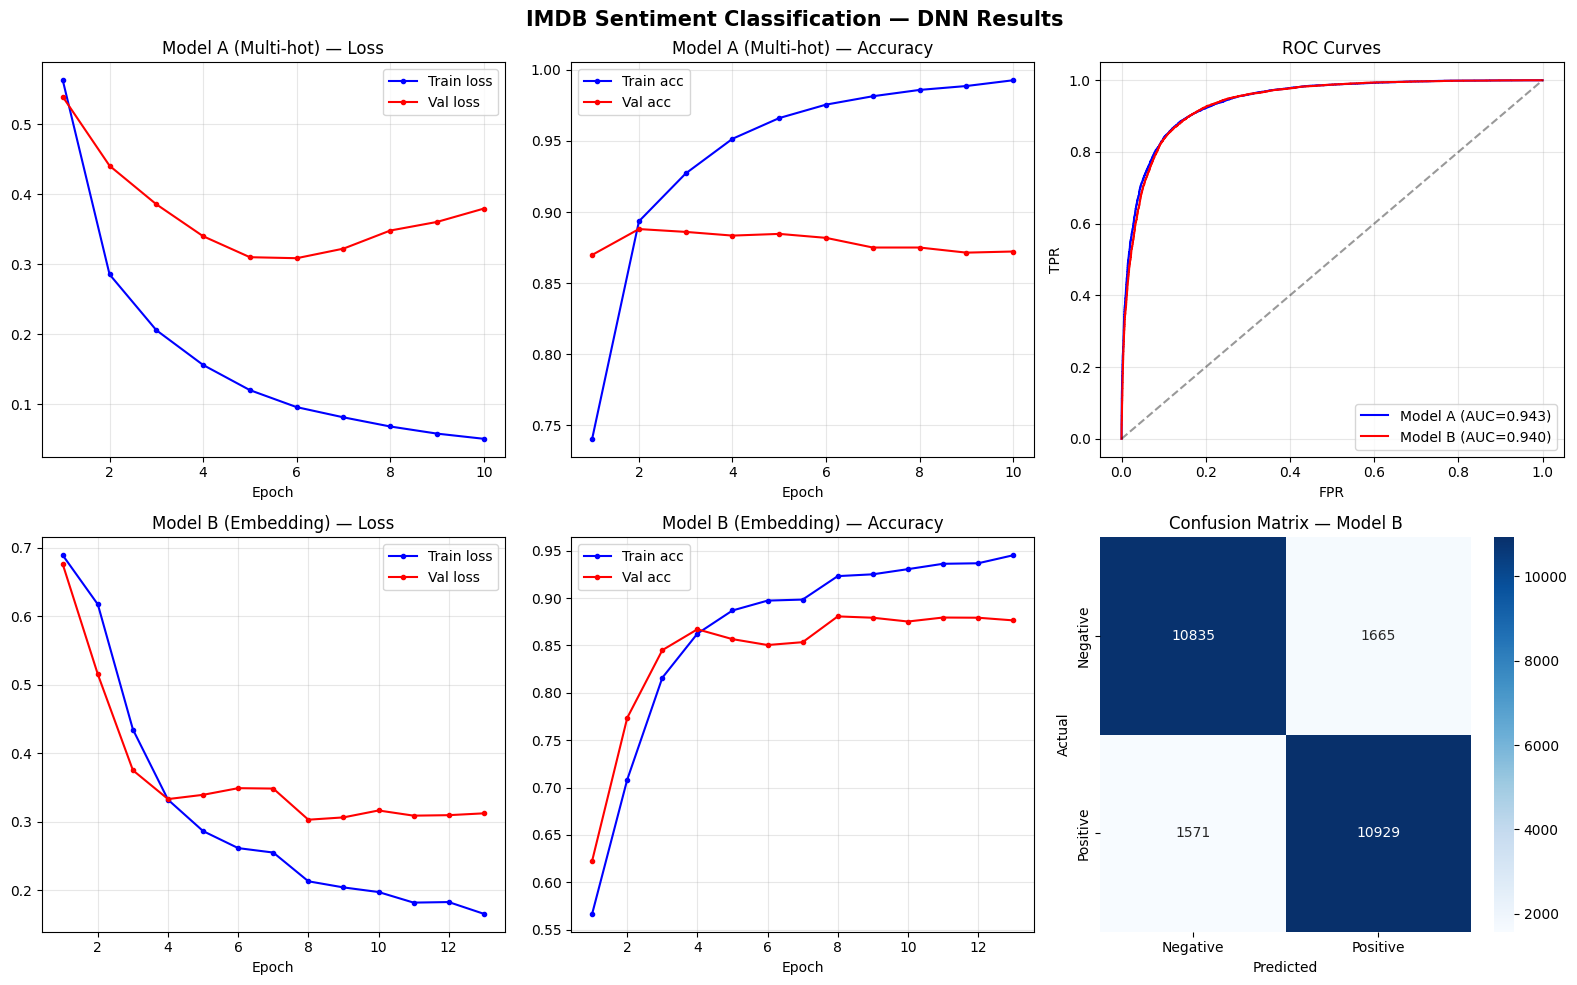


Plot saved → assignment1_results.png


In [10]:
# ──────────────────────────────────────────────────────────
# 8. PLOTTING
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("IMDB Sentiment Classification — DNN Results", fontsize=15, fontweight="bold")

def plot_history(ax_loss, ax_acc, hist, title):
    epochs_ran = range(1, len(hist.history["loss"]) + 1)
    ax_loss.plot(epochs_ran, hist.history["loss"],     "b-o", ms=3, label="Train loss")
    ax_loss.plot(epochs_ran, hist.history["val_loss"], "r-o", ms=3, label="Val loss")
    ax_loss.set_title(f"{title} — Loss"); ax_loss.set_xlabel("Epoch"); ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(epochs_ran, hist.history["accuracy"],     "b-o", ms=3, label="Train acc")
    ax_acc.plot(epochs_ran, hist.history["val_accuracy"], "r-o", ms=3, label="Val acc")
    ax_acc.set_title(f"{title} — Accuracy"); ax_acc.set_xlabel("Epoch"); ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

plot_history(axes[0,0], axes[0,1], history_a, "Model A (Multi-hot)")
plot_history(axes[1,0], axes[1,1], history_b, "Model B (Embedding)")

# ROC curves for both models
ax_roc = axes[0, 2]
for model, x_test_, name, c in [(model_a, x_test_mh,  "Model A", "blue"),
                                  (model_b, x_test_seq, "Model B", "red")]:
    probs = model.predict(x_test_, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax_roc.plot(fpr, tpr, color=c, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
ax_roc.plot([0,1],[0,1],"k--", alpha=0.4)
ax_roc.set_title("ROC Curves"); ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.legend(); ax_roc.grid(True, alpha=0.3)

# Confusion matrix for best model
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_b)
ax_cm = axes[1, 2]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax_cm,
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])
ax_cm.set_title("Confusion Matrix — Model B")
ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("assignment1_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → assignment1_results.png")

In [11]:
# ──────────────────────────────────────────────────────────
# 9. PREDICT ON CUSTOM TEXT
# ──────────────────────────────────────────────────────────
def predict_sentiment(review_text: str, model=model_b,
                      max_len=MAX_LEN, num_words=NUM_WORDS):
    """
    Encode a raw text review and predict sentiment.
    Uses simple whitespace tokenisation mapped to IMDB word index.
    """
    wi = imdb.get_word_index()
    tokens = [wi.get(w.lower().strip(".,!?\"'"), 2) + 3
              for w in review_text.split()]
    # clip to vocabulary
    tokens = [t if t < num_words else 2 for t in tokens]
    padded = keras.preprocessing.sequence.pad_sequences(
        [tokens], maxlen=max_len, padding="post", truncating="post")
    prob = model.predict(padded, verbose=0)[0][0]
    label = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😞"
    return label, float(prob)

test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat the entire time.",
    "Terrible film. Boring plot, wooden acting, and a waste of two hours. I walked out halfway through.",
    "It was okay. Some parts were good but overall it felt mediocre and forgettable.",
]

print("\n" + "="*55)
print("CUSTOM PREDICTION DEMO")
print("="*55)
for review in test_reviews:
    label, prob = predict_sentiment(review)
    print(f"\nReview : {review[:80]}…")
    print(f"Result : {label}  (confidence: {prob:.3f})")

print("\n✅ Assignment 1 complete!")



CUSTOM PREDICTION DEMO

Review : This movie was absolutely fantastic! The acting was superb and the story kept me…
Result : POSITIVE 😊  (confidence: 0.746)

Review : Terrible film. Boring plot, wooden acting, and a waste of two hours. I walked ou…
Result : NEGATIVE 😞  (confidence: 0.018)

Review : It was okay. Some parts were good but overall it felt mediocre and forgettable.…
Result : NEGATIVE 😞  (confidence: 0.275)

✅ Assignment 1 complete!
